In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import Sequence, Tuple

from dispertorch import ConstantEps, ConstantIndex
from metashapes.shape import Rectangle, Ellipse

from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model, Layer
from metarcwa.model.adapters import from_dispertorch, from_metashapes
from metarcwa import Config, Solver, Factorization, Observables
from metarcwa.solver.harmonics import harmonic_index_map

In [2]:
def build_model(w: torch.Tensor,
                h: torch.Tensor,
                angle: torch.Tensor,
                thickness: torch.Tensor,
                eps_solid: ConstantEps,
                eps_void: ConstantEps,
                eps_inc: ConstantEps,
                eps_trans: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor) -> Model:
    """Build a single-patterned-layer Model between two half-spaces.

    The layer's in-plane permittivity is ``shape`` (filled with ``eps_solid``)
    embedded in a background of ``eps_void``, on a square lattice of period
    ``period``. The layer sits between an incidence half-space (``eps_inc``)
    and a transmission half-space (``eps_trans``).

    Parameters
    ----------
    w: torch.Tensor
        Bar width.
    thickness : torch.Tensor
        Layer thickness.
    eps_solid, eps_void : ConstantEps
        Dispersion models for the shape's fill / background, wrapped into
        ``IsotropicMedium`` via ``from_dispertorch``.
    eps_inc, eps_trans : ConstantEps
        Dispersion models for the incidence / transmission half-spaces.
    period : torch.Tensor
        Square lattice period (px = py).
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium_inc = IsotropicMedium(from_dispertorch(eps_inc))
    medium_trans = IsotropicMedium(from_dispertorch(eps_trans))
    medium_solid = IsotropicMedium(from_dispertorch(eps_solid))
    medium_void = IsotropicMedium(from_dispertorch(eps_void))

    lattice = Lattice.rectangular(px=period, py=period)
    layer = Layer(medium_solid, thickness, medium_void, 
                  from_metashapes(Ellipse((period/2, period/2), (w, h), angle)))
    stack = Stack(medium_inc, [layer], medium_trans, lattice)
    src = Source(wl, theta, phi=0.0)

    return Model(stack, src)


def build_config(dtype: torch.dtype, device: torch.device,
                 m: int, n: int, nx: int, ny: int,
                 factorization: Factorization | None,
                 truncation: str = "circular",
                 modesolver: str = "eig") -> Config:
    """Build a Config from a Factorization instance directly (or None to
    disable TVF). Kept separate from `Factorization(...)` construction so
    callers can build variant configs via `dataclasses.replace(base_config, ...)`.
    """
    return Config(dtype, device, m=m, n=n, nx=nx, ny=ny,
                  truncation=truncation, factorization=factorization, modesolver=modesolver)
    
def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor, torch.Tensor,
                                                        torch.Tensor, torch.Tensor]:
    """Solve the stack and return specular-order power R/T for both polarizations.

    Same convention as ``interface.ipynb``'s ``compute_rt``: reflectance is
    ``|r|**2``; transmittance additionally carries the Poynting-flux ratio
    ``Re(n_sub*cos(theta_t)) / Re(n_inc*cos(theta_i))`` between the incidence
    and transmission half-spaces (unaffected by whatever finite layer sits in
    between -- it depends only on the two half-spaces and the angle).

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Shape ``[N_wl, N_theta, N_phi]``, matching ``Source``'s sweep axes.
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')
    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)
    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff * torch.abs(ts.cpu())**2
    Tp = coeff * torch.abs(tp.cpu())**2
    return Rs, Rp, Ts, Tp

Eigensolver time: 24.973369359970093 s


[W730 15:32:27.992412305 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 7847542784 bytes (free: 3699507200, total: 25250627584).


Eigensolver time: 24.072316646575928 s


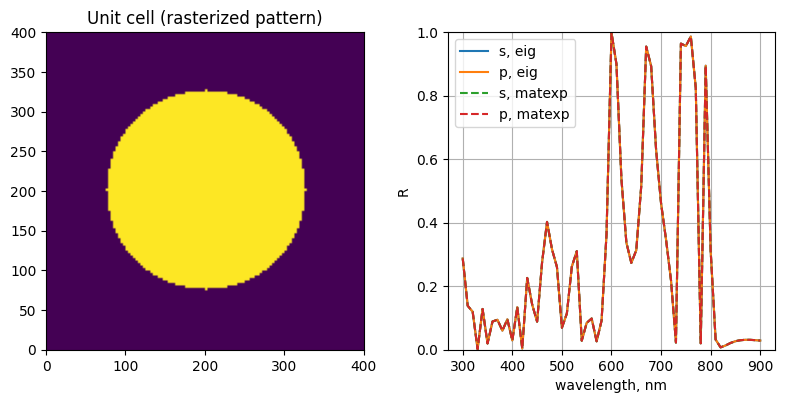

In [ ]:
# Define config
dtype = torch.float32
device = "cuda:0"
m = 10
n = 10
nx = 128
ny = 128
truncation = "circular"
factorization = Factorization(method="Jones")


# Define model parameters
eps_inc  = ConstantEps(1)
eps_solid  = ConstantIndex(3.8, k=0.0)    
eps_subs = ConstantIndex(1.46)

w = torch.tensor(250.0)
h = torch.tensor(250.0)
angle = 0.0
thickness = torch.tensor(200.0)   # nm
period    = 400

wl    = torch.linspace(300.0, 900.0, 61)
theta = torch.tensor([0.0])       # ~17 deg, fixed

model = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc, eps_subs, period, wl, theta)

# Eigensolver
modesolver = "eig"
config_eig = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_eig, Rp_eig, Ts_eig, Tp_eig = compute_rt(model, config_eig)
end = time.time()
print(f"Eigensolver time: {end - start} s")

# Matrix exponential solver
modesolver = "matexp"
config_matexp = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_matexp, Rp_matexp, Ts_matexp, Tp_matexp = compute_rt(model, config_matexp)
end = time.time()
print(f"Eigensolver time: {end - start} s")

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(model.spec(nx=nx, ny=ny).layers[0].pattern.cpu(), origin="lower", extent=(0, period, 0, period))
plt.title("Unit cell (rasterized pattern)")

plt.subplot(122)
plt.plot(wl, Rs_eig[:,0,0], label='s, eig')
plt.plot(wl, Rp_eig[:,0,0], label='p, eig')
plt.plot(wl, Rs_matexp[:,0,0], '--', label='s, matexp')
plt.plot(wl, Rp_matexp[:,0,0], '--', label='p, matexp')
plt.grid()
plt.ylabel('R')
plt.xlabel('wavelength, nm')
plt.legend()
plt.ylim([0, 1.0])

plt.tight_layout()